# Analysis of open loop stability data from 20251026

I am going to investigate the potential impact of m1m3 thermals on zernikes for the open loop stability tests executed in 20251026.

There are 4 runs done at different positions and different filters:

1 - Az: 180 El: 60 Rot: 0 g-band -> UNSTABLE

2 - Az: 90 El: 60 Rot: 0 g-band -> STABLE

3 - Az: 180 El: 60 Rot: 0 i-band -> UNSTABLE

4 - Az: 90 El: 60 Rot: 0 i-band -> STABLE

I will start by calculating the temperature gradients during that night.

In [31]:
import lsst_efd_client
import matplotlib.pyplot as plt
import numpy as np

import astropy.units as u
from astropy.time import Time

from lsst.ts.m1m3.utils import ThermocoupleAnalysis

from lsst.summit.utils import ConsDbClient

from batoid_rubin import LSSTBuilder
import batoid

import os
os.environ["no_proxy"] += ",.consdb"



In [2]:
efd_client = lsst_efd_client.EfdClient("usdf_efd")

In [32]:
#consdb_client = ConsDbClient(
#    "https://usdf-rsp-dev.slac.stanford.edu/consdb/",
#    token=os.environ["CONSDB_TOKEN"],
#)

client = ConsDbClient("http://consdb-pq.consdb:8080/consdb")

In [5]:
thermocouple_analysis = ThermocoupleAnalysis(
    efd_client,
)

In [6]:
dayobs = 20251026

In [7]:
start = Time(
    "2025-10-27T00:00:00",
    format="isot",
    scale="utc",
)
end = Time(
    "2025-10-27T10:00:00",
    format="isot",
    scale="utc",
)

In [8]:
close_loop_status = await efd_client.select_time_series(
    "lsst.sal.MTAOS.logevent_closedLoopState",
    ["state"],
    start=start,
    end=end,
)

In [9]:
close_loop_status

""


In [10]:
await thermocouple_analysis.load(
    start_time=start,
    end_time=end,
    do_remove_cold_junction=True,
    do_remove_offsets=True,
)

In [11]:
gradients = thermocouple_analysis.calculate_gradients_xyz_r()

In [12]:
run_times = [
    (
        Time(
            "2025-10-27T00:54:26",
            format="isot",
            scale="utc",
        ).to_value("plot_date"),
        Time(
            "2025-10-27T01:22:18",
            format="isot",
            scale="utc",
        ).to_value("plot_date")
    ),
    (
        Time(
            "2025-10-27T02:20:26",
            format="isot",
            scale="utc",
        ).to_value("plot_date"),
        Time(
            "2025-10-27T02:48:18",
            format="isot",
            scale="utc",
        ).to_value("plot_date")
    ),
    (
        Time(
            "2025-10-27T05:45:46",
            format="isot",
            scale="utc",
        ).to_value("plot_date"),
        Time(
            "2025-10-27T06:14:03",
            format="isot",
            scale="utc",
        ).to_value("plot_date")
    ),
    (
        Time(
            "2025-10-27T07:05:23",
            format="isot",
            scale="utc",
        ).to_value("plot_date"),
        Time(
            "2025-10-27T07:33:18",
            format="isot",
            scale="utc",
        ).to_value("plot_date")
    ),
]

state = ["red", "skyblue", "red", "skyblue"] 

NameError: name 'z4_changes' is not defined

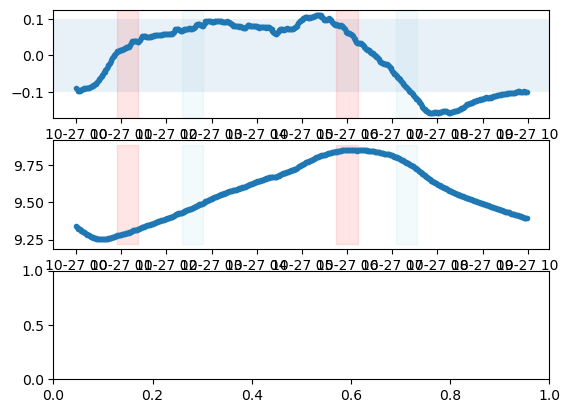

In [13]:
fig, ax = plt.subplots(3)

ax[0].plot(
    gradients.z_gradient,
    ".",
    label="z-gradient",
)

xlim = ax[0].get_xlim()
ylim = ax[0].get_ylim()

ax[0].fill_between(
    xlim,
    [-0.1, -0.1],
    [+0.1, +0.1],
    alpha=0.1
)

for time_range, color in zip(run_times, state):
    ax[0].fill_betweenx(
        ylim,
        [time_range[0], time_range[0]],
        [time_range[1], time_range[1]],
        color=color,
        alpha=0.1,
    )

ax[0].set_xlim(xlim)
ax[0].set_ylim(ylim)

ax[1].plot(
    thermocouple_analysis.bulk_glass_temperature_metrics.mean_temp,
    ".",
)

ylim = ax[1].get_ylim()

for time_range, color in zip(run_times, state):
    ax[1].fill_betweenx(
        ylim,
        [time_range[0], time_range[0]],
        [time_range[1], time_range[1]],
        color=color,
        alpha=0.1,
    )

ax[2].plot(
    gradients.z_gradient.index,
    z4_changes-np.mean(z4_changes),
    ".",
)
ax[2].plot(
    time_axis,
    visit_info["z4"],
    ".",
)

ylim = ax[2].get_ylim()

for time_range, color in zip(run_times, state):
    ax[2].fill_betweenx(
        ylim,
        [time_range[0], time_range[0]],
        [time_range[1], time_range[1]],
        color=color,
        alpha=0.1,
    )
ax[2].grid()

ax[0].set_ylabel("Temp. Gradient")
ax[1].set_ylabel("Bulk Temp.")
ax[2].set_ylabel("Z4 change")

In [17]:
os.environ["BATOID_RUBIN_DATA_DIR"] = os.path.join(os.environ["HOME"], "batoid_rubin_data")

In [18]:
if not os.path.exists(os.environ["BATOID_RUBIN_DATA_DIR"]):
    raise RuntimeError(
        f"The batoid data dir {os.environ['BATOID_RUBIN_DATA_DIR']} "
        "does not exists. Create it before continuing."
    )

In [19]:
fiducial = batoid.Optic.fromYaml("LSST_r.yaml")
wavelength = 622e-9
builder = LSSTBuilder(
    fiducial,
    # fea_dir="/home/tribeiro/.batoid/fea_legacy",
    # bend_dir="/home/tribeiro/.batoid/bend",
    # ccd_height_map_dir="/home/tribeiro/.batoid/ccd_height_map",
    # Following options change the original coords/signs/units to match the ones used by MTAOS
    dof_coord_system="OCS",
    flip_m2_bending_modes=False,
    dof_angle_units="degree",
)

In [20]:
def zk_deviation(builder, thx, thy, dof):
    """
    Parameters
    ----------
    builder : LSSTBuilder
    thx, thy : float
        Field angle in OCS in radians
    dof : array
        50-element degree-of-freedom vector:

        0 = m2_dz [µm]
        1,2 = m2_dx/dy [µm]
        3,4 = m2_rx/ry [degree]
        5 = cam_dz [µm]
        6,7 = cam_dx/dy [µm]
        8,9 = cam_rx/ry [degree]
        10-29 = m1m3 bending modes [µm]
        30-49 = m2 bending modes [µm]

    Returns
    -------
    zk_dev : array
        Zernike deviation (total - intrinsic) in microns in OCS.
        zk_dev[j] means Noll index j.
        So focus (Z4) is zk_dev[4].        
    """
    perturbed = builder.with_aos_dof(dof).build()
    zk0 = batoid.zernikeGQ(
        fiducial,
        thx, thy,
        wavelength,
        rings=10,
        jmax=28,
        eps=0.612
    )
    zk1 = batoid.zernikeGQ(
        perturbed,
        thx, thy,
        wavelength,
        rings=10,
        jmax=28,
        eps=0.612
    )
    return (zk1 - zk0) * wavelength * 1e6 # => µm


In [21]:
field_angles = np.deg2rad(
    np.array(
        [
            [-1.1902777777777778, -1.1902777777777778],
            [-1.2549166666666665, -1.1903333333333332],
            [-1.1902777777777778, 1.1902777777777778],
            [-1.1903333333333332, 1.2549166666666665],
            [1.1902777777777778, -1.1902777777777778],
            [1.1903333333333332, -1.2549166666666665],
            [1.1902777777777778, 1.1902777777777778],
            [1.2549166666666665, 1.1903333333333332],
        ]
    )
)

field_angles_deg = np.array(
    [
        [-1.1902777777777778, -1.1902777777777778],
        [-1.2549166666666665, -1.1903333333333332],
        [-1.1902777777777778, 1.1902777777777778],
        [-1.1903333333333332, 1.2549166666666665],
        [1.1902777777777778, -1.1902777777777778],
        [1.1903333333333332, -1.2549166666666665],
        [1.1902777777777778, 1.1902777777777778],
        [1.2549166666666665, 1.1903333333333332],
    ]
)

In [22]:
dof = np.zeros(50)

In [23]:
perturbed = builder.with_m1m3_temperature(m1m3_TzGrad=0.00, m1m3_TBulk=0.0) #.build()

z4_changes = np.zeros(len(gradients.z_gradient))

for i, (gradient, bulk_temp) in enumerate(
    zip(
        gradients.z_gradient, 
        thermocouple_analysis.bulk_glass_temperature_metrics.mean_temp
    )
):
    perturbed = builder.with_m1m3_temperature(m1m3_TzGrad=gradient, m1m3_TBulk=bulk_temp)
    
    zk_round_trip_1 = np.array(
        [
            zk_deviation(
                perturbed, 
                field_angles[0][0],
                field_angles[0][1], 
                dof,
            ),
            zk_deviation(
                perturbed, 
                field_angles[2][0], 
                field_angles[2][1], 
                dof,
            ),
            zk_deviation(
                perturbed, 
                field_angles[4][0], 
                field_angles[4][1], 
                dof,
            ),
            zk_deviation(
                perturbed,
                field_angles[6][0], 
                field_angles[6][1], 
                dof,
            ),
        ]
    )
    z4_changes[i] = zk_round_trip_1[0][4]


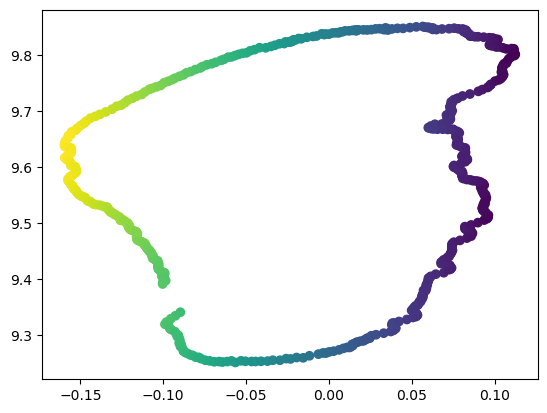

In [41]:

f,ax = plt.subplots(1,1)
_ = ax.scatter(gradients.z_gradient,thermocouple_analysis.bulk_glass_temperature_metrics.mean_temp,c=z4_changes)

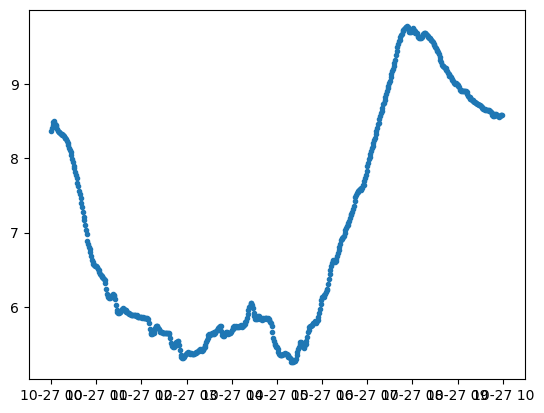

In [25]:
plt.plot(
    gradients.z_gradient.index,
    z4_changes,
    ".",
)

In [29]:
query = f"""
SELECT
ccdvisit1_quicklook.z4,
e.seq_num,
e.exposure_id,
e.obs_end,
e.obs_start
FROM
cdb_lsstcam.ccdvisit1_quicklook AS ccdvisit1_quicklook,
cdb_lsstcam.ccdvisit1 AS ccdvisit1,
cdb_lsstcam.exposure AS e
WHERE
e.day_obs = {dayobs} AND
ccdvisit1.ccdvisit_id = ccdvisit1_quicklook.ccdvisit_id AND
ccdvisit1.visit_id = e.exposure_id
"""

In [33]:
visit_info = client.query(query)

In [34]:
time_axis = np.array(
    [
        Time(t).to_value("plot_date") for t in visit_info["obs_start"]
    ]
)

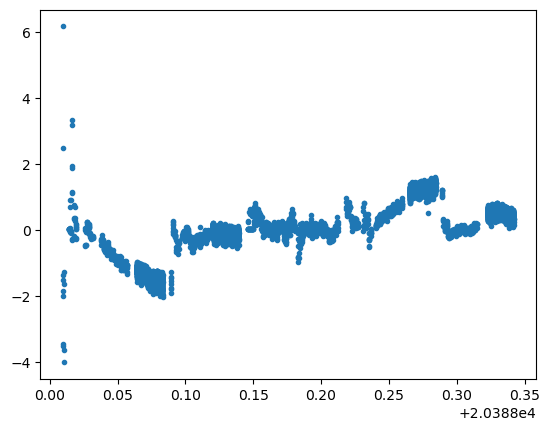

In [35]:
plt.plot(
    time_axis,
    visit_info["z4"],
    ".",
)

In [36]:
visit_info["obs_start"]

2025-10-26T23:46:14.947000
2025-10-26T23:46:14.947000
2025-10-26T23:46:14.947000
2025-10-26T23:46:14.947000
2025-10-26T23:46:14.947000
2025-10-26T23:46:14.947000
2025-10-26T23:46:14.947000
2025-10-26T23:46:14.947000
2025-10-26T23:46:14.947000
2025-10-26T23:46:14.947000
2025-10-26T23:46:14.947000


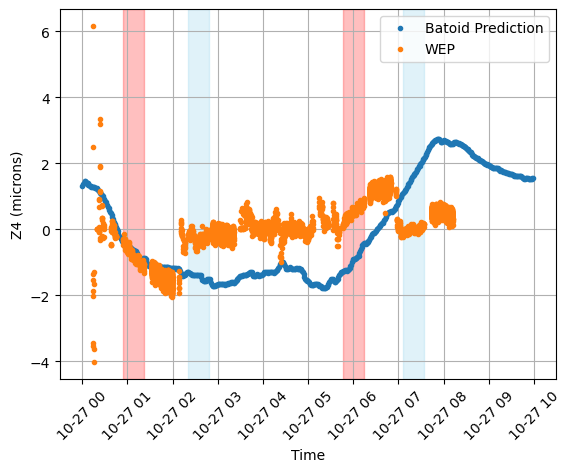

In [37]:
fig, ax = plt.subplots(1)


ax.plot(
    gradients.z_gradient.index,
    z4_changes-np.mean(z4_changes),
    ".",
    label="Batoid Prediction",
)
ax.plot(
    time_axis,
    visit_info["z4"],
    ".",
    label="WEP",
)

ylim = ax.get_ylim()

for time_range, color in zip(run_times, state):
    ax.fill_betweenx(
        ylim,
        [time_range[0], time_range[0]],
        [time_range[1], time_range[1]],
        color=color,
        alpha=0.25,
    )
ax.grid()
ax.set_ylim(ylim)
ax.set_ylabel("Z4 (microns)")
ax.set_xlabel("Time")
ax.tick_params(axis='x', labelrotation=45)
ax.legend()